In [62]:
# import mitsuba
import math

# import drjit
import drjit as dr
import matplotlib.pyplot as plt
import numpy as np

import mitsuba as mi

# colocar el valor de spectral
mi.set_variant("cuda_ad_spectral")

from mitsuba import ScalarTransform4f as T


In [63]:
scene_xml_path = r"C:\Users\mgefr\Documents\1UIS\proyecto-grado\output\static\scene_thermal.xml"
scene_from_xml = mi.load_file(scene_xml_path)
print(scene_from_xml)

Scene[
  children = [
    VolumetricMisPathIntegrator[
      max_depth = 16,
      rr_depth = 5
    ],
    PerspectiveCamera[
      x_fov = [34.0221],
      near_clip = 0.01,
      far_clip = 10000,
      film = SpecFilm[
        size = [256, 256],
        crop_size = [256, 256],
        crop_offset = [0, 0],
        sample_border = 0,
        compensate = 0,
        filter = BoxFilter[],
        file_format = OpenEXR,
        pixel_format = multichannel,
        component_format = float16,
        film_srf = [
          RegularSpectrum[
            distr = ContinuousDistribution[
              size = 12,
              range = [7666.67, 14333.3],
              integral = [6666.67],
              pdf = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
            ]
          ]
        ],
        sensor response functions = (
          RegularSpectrum[
            distr = ContinuousDistribution[
              size = 2,
              range = [7666.67, 8333.33],
              integral = [666.667],
    

In [64]:
image_test = mi.render(scene_from_xml)

In [65]:
print(image_test.shape)

(256, 256, 10)


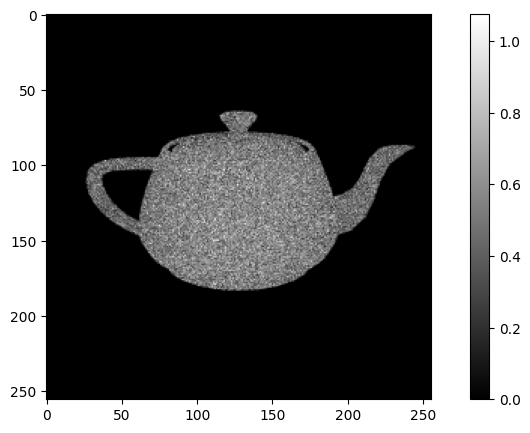

In [66]:
plt.figure(figsize=(10, 5))
plt.imshow(image_test[:,:,0], cmap='gray')
plt.colorbar()

In [25]:
def gaussian(lambdas: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    """
    Calculate the Gaussian function value at x with mean mu and standard deviation sigma.
    Args:
        lambdas (np.ndarray): The input values (wavelengths).
        mu (float): The mean of the Gaussian.
        sigma (float): The standard deviation of the Gaussian.
    """
    return dr.exp(-0.5 * ((lambdas - mu) / sigma) ** 2) / (sigma * dr.sqrt(2 * dr.pi))
    # return np.exp(-0.5 * ((lambdas - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

In [26]:
def camera_response_gaussian(
    wavelength: int, sigma: float, k: float = 3, n_wavelents: int = 5
):
    """
    Camera response function

    Args:
        wavelength (int): Wavelength in nm.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """

    # define the wavelength range (n values)
    wavelengths = np.linspace(
        wavelength - k * sigma, wavelength + k * sigma, n_wavelents
    )

    # define the Gaussian function
    gaussian_values = gaussian(wavelengths, wavelength, sigma)

    # normalize the Gaussian function (0,1)
    gaussian_values = (gaussian_values - dr.min(gaussian_values)) / (
        dr.max(gaussian_values) - dr.min(gaussian_values)
    )

    return wavelengths, gaussian_values

In [27]:
def load_sensor_spectral(
    r: float,
    phi: float,
    theta: float,
    wave_lengths: np.ndarray,
    sigma: float,
    k: float = 3,
    n_wavelents: int = 5,
):
    """
    Load a sensor with Gaussian response.

    Args:
        r (float): Radius of the sensor.
        phi (float): Azimuthal angle in degrees.
        theta (float): Polar angle in degrees.
        wave_lengths (np.ndarray): Wavelengths for the Gaussian response.
        sigma (float): Standard deviation of the Gaussian.
        k (float, optional): Number of standard deviations. Default is 3.
        n_wavelents (int, optional): Number of wavelengths. Default is 5.
    """
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    film_dic = {
        "type": "specfilm",
        "width": 256,
        "height": 256,
        "rfilter": {
            "type": "tent",
        },
    }

    # create sensor uniform
    distancia = wave_lengths[1] - wave_lengths[0]
    separar = distancia // 2

    for wave_length in wave_lengths:
        w_min = int(wave_length - separar)
        w_max = int(wave_length + separar)

        values = "1.0, 1.0"

        # if w_min > 12000:
        #     values = '1.0, 1.0'

        film_dic[f"band_{wave_length}"] = {
            "type": "regular",
            "wavelength_min": w_min,
            "wavelength_max": w_max,
            "values": values,
        }

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 1},
        "film": film_dic,
    }

In [28]:
def load_sensor_rgb(r, phi, theta):
    z = r * dr.sin(math.radians(theta))
    y = r * dr.cos(math.radians(theta)) * dr.sin(math.radians(phi))
    x = r * dr.cos(math.radians(theta)) * dr.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 16},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {
                "type": "tent",
            },
            "pixel_format": "rgb",
        },
    }


In [29]:
wave_lengths = np.linspace(8000, 14000, 49).astype(int)

sigma = 10
r = 35
phi = 0
theta = 0
k = 3
n = 15

sensor_espectral = mi.load_dict(
    load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
)
sensor_rgb = mi.load_dict(load_sensor_rgb(r, phi, theta))

In [30]:
from scipy import constants as const


def blackbody_radiance_nm(wavelengths_nm, temperature):
    """
    Compute spectral radiance B(λ, T) of a black body
    using scipy constants.

    Args:
        wavelengths_nm: array-like of wavelengths in nanometers (nm).
        temperature:    temperature in Kelvin (K).

    Returns:
        numpy array of spectral radiance in W·sr⁻¹·m⁻²·nm⁻¹.
    """
    # Convert wavelengths to meters
    wavelengths_m = np.array(wavelengths_nm, dtype=float) * 1e-9

    # Planck's law for spectral radiance per meter: W·sr⁻¹·m⁻²·m⁻¹
    B_m = (
        (2 * const.h * const.c**2)
        / (wavelengths_m**5)
        / (np.exp(const.h * const.c / (wavelengths_m * const.k * temperature)) - 1)
    )

    # Convert from per meter to per nanometer: 1 m = 1e9 nm
    B_nm = B_m * 1e-9

    return B_nm


radiance = blackbody_radiance_nm(wave_lengths, 5000)

# Idea para asignar una emisiviadad y cuerpo negro

## Cargar datos de emisividad

In [43]:
dataBaseName = np.load("../assets/reference_data/matName_FullDatabase.npy", allow_pickle=True).item()[
    "matName"
]
dataBaseName = dataBaseName.squeeze()
dataBaseName = np.hstack(dataBaseName)  # lista de nombres de los materiales

dataBaseLib = np.load("../assets/reference_data/matLib_FullDatabase.npy", allow_pickle=True).item()[
    "matLib"
]
dataBaseLib = dataBaseLib[::-1, :]  # Reverso el orden de la base de datos

# vamos a asumir que las 49 firmas espectrales coinciden con las 49 longitudes de onda de la escena

print(dataBaseName.shape)
print(dataBaseLib.shape)


(30,)
(49, 30)


In [32]:
print(dataBaseName)

['sky' 'asphalt' 'tilePavement' 'cinderblock' 'brick' 'wall' 'marble'
 'stone' 'soil' 'al' 'weatheredMetal' 'brass' 'al2o3' 'oxidizedSteel'
 'iron' 'carpaint' 'plasticPaint' 'yellowSpray' 'carwindow' 'crystalGlass'
 'tire' 'cloths' 'card' 'tree' 'grass' 'flower' 'water' 'human' 'bark'
 'concrete']


(49,)


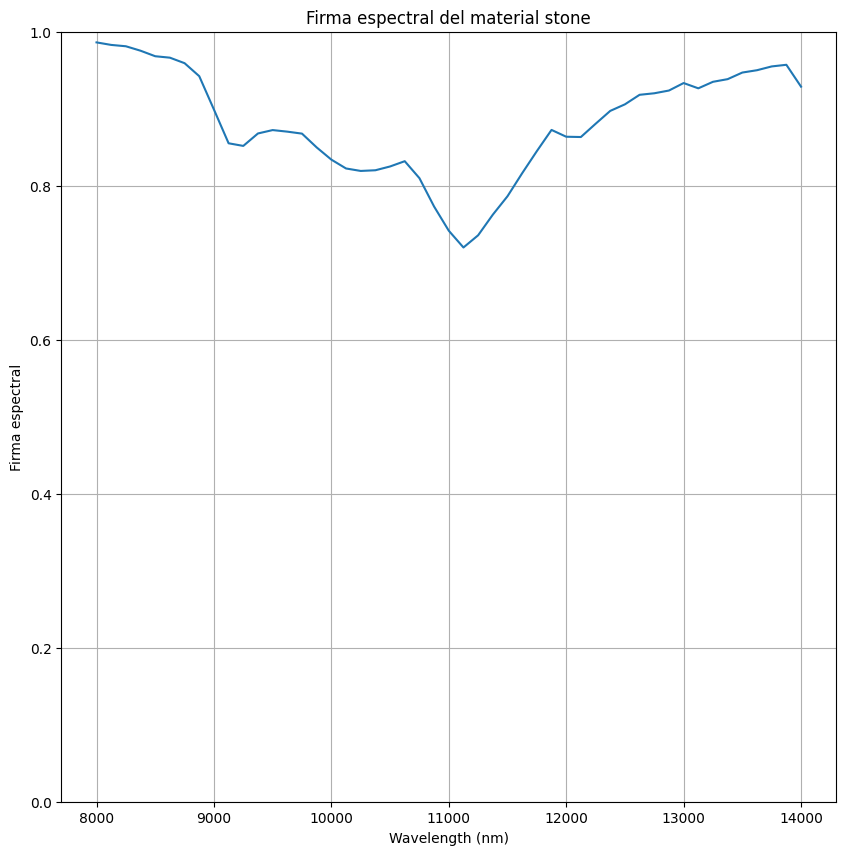

In [33]:
material = "stone"  # escoge el material que quieres
indice_material = np.where(dataBaseName == material)[0][
    0
]  # busca el indice del material en la base de datos

firma = dataBaseLib[:, indice_material]  # firma espectral del material

print(firma.shape)

# plot
plt.figure(figsize=(10, 10))
plt.plot(wave_lengths, firma)
plt.title(f"Firma espectral del material {material}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Firma espectral")
plt.ylim(0, 1)
plt.grid()
plt.show()

### Definir blackbody con la emisividad

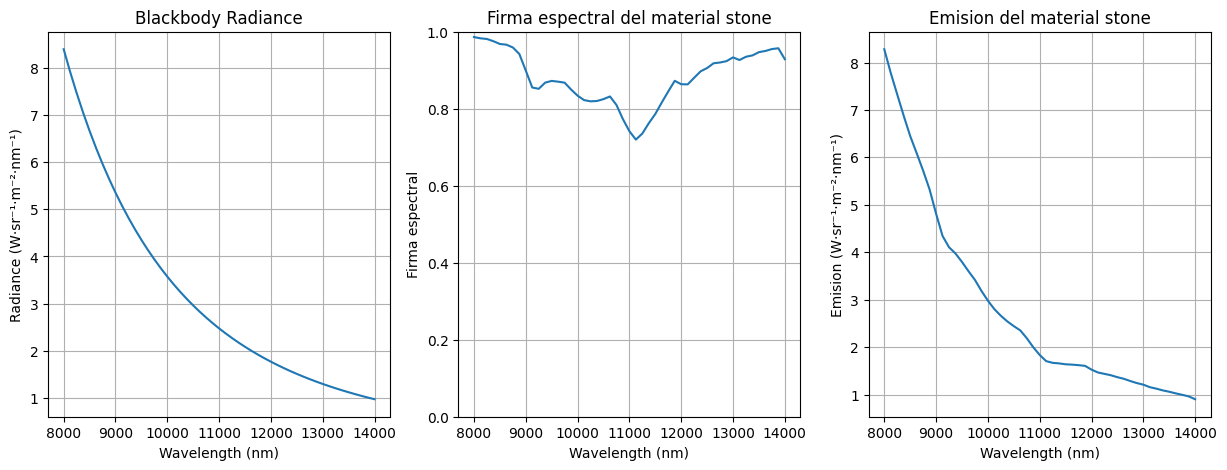

In [34]:
temperatura = 5000  # temperatura objeto

black_body = blackbody_radiance_nm(wave_lengths, temperatura)  # radiancia del objeto

emision = black_body * firma  # emision del objeto

# subplots
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(wave_lengths, black_body)
plt.title("Blackbody Radiance")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance (W·sr⁻¹·m⁻²·nm⁻¹)")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(wave_lengths, firma)
plt.title(f"Firma espectral del material {material}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Firma espectral")
plt.ylim(0, 1)
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(wave_lengths, emision)
plt.title(f"Emision del material {material}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Emision (W·sr⁻¹·m⁻²·nm⁻¹)")
plt.grid()

plt.show()


### Creacion del objeto con esa emision en especifico

In [35]:
def lista_a_string(valores):
    return ", ".join(str(v) for v in valores)

In [36]:
dragon = {
    "type": "obj",
    "filename": "scenes/objects/Dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    # 'bsdf': {
    #     'type': 'diffuse',
    #     'reflectance': {
    #         'type': 'rgb',
    #         'value': [0.5, 0.5, 0.5]
    #     }
    # },
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

### Creacion de sensor (el mismo anterior)

In [37]:
sigma = 10
r = 35
phi = -45
theta = 0
k = 3
n = 15

sensor_espectral = mi.load_dict(
    load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
)
sensor_rgb = mi.load_dict(load_sensor_rgb(r, phi, theta))

### Creaciond de la escena

In [ ]:
scene = mi.load_dict(
    {
        "type": "scene",
        "integrator": {
            "type": "path",
        },
        # 'emitter': {
        #     'type' : 'constant'
        # },
        #"dragon": dragon,
    }
)


### Renderizacion

In [16]:
imagen_espectral = mi.render(scene, sensor=sensor_espectral, spp=1024 * 16)
imagen_rgb = mi.render(scene, sensor=sensor_rgb, spp=1024)

In [17]:
print("Imagen RGB:")
print(imagen_rgb.shape)
print(np.min(imagen_rgb))
print(np.max(imagen_rgb))

print("\nImagen espectral:")
print(imagen_espectral.shape)
print(np.min(imagen_espectral))
print(np.max(imagen_espectral))

Imagen RGB:
(256, 256, 3)
0.0
0.0

Imagen espectral:
(256, 256, 49)
0.0
1028.1577


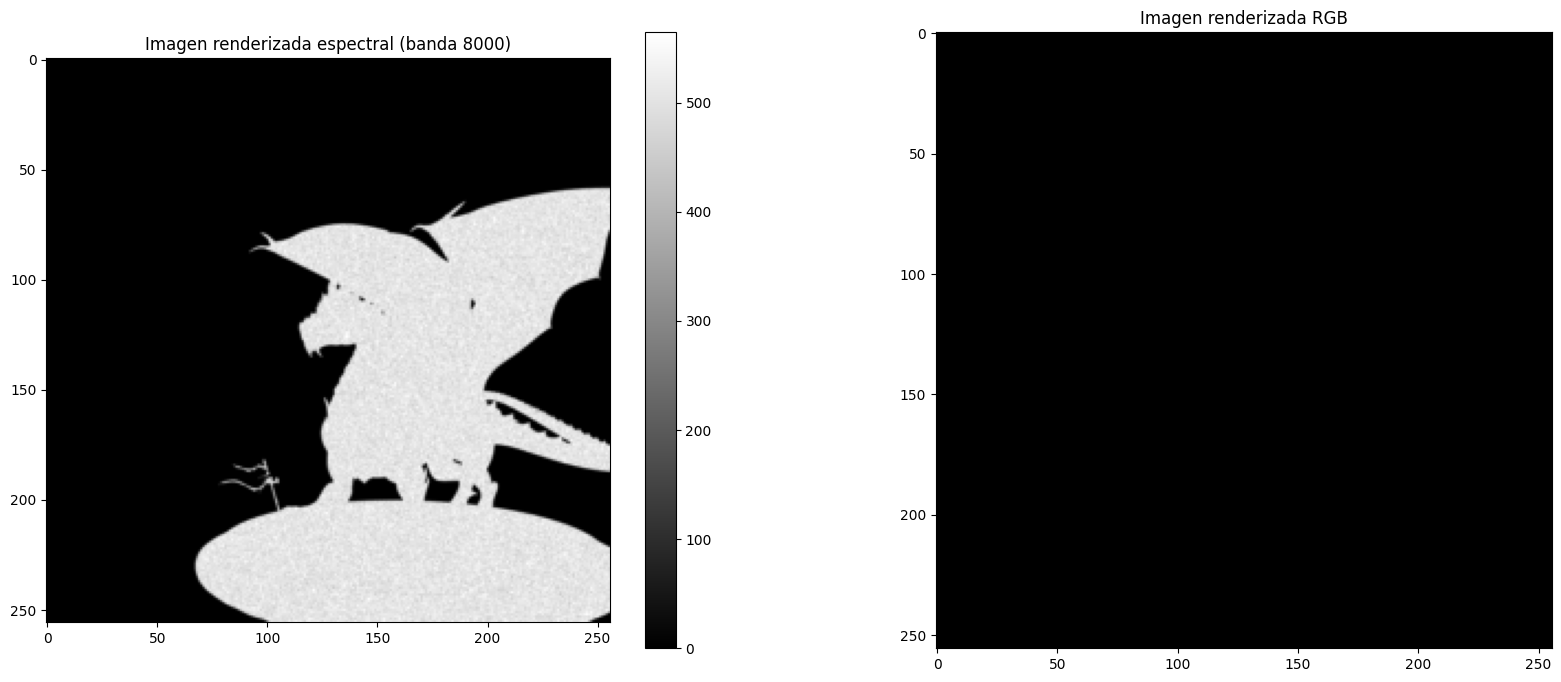

In [18]:
banda = 0

plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(imagen_espectral[:, :, banda], cmap="gray")
plt.colorbar()
plt.title("Imagen renderizada espectral (banda {})".format(wave_lengths[banda]))

plt.subplot(1, 2, 2)
plt.imshow(imagen_rgb)
plt.title("Imagen renderizada RGB")


plt.show()

In [19]:
shapes = scene.emitters()

print(shapes)


[AreaLight[
  radiance = IrregularSpectrum[
    distr = IrregularContinuousDistribution[
      size = 49,
      nodes = [8000, 8125, 8250, 8375, 8500,    39 skipped .., 13500, 13625, 13750, 13875, 14000],
      integral = [16796.9],
      pdf = [8.28011, 7.77917, 7.32604, 6.87665, 6.45051,    39 skipped .., 1.05877, 1.02475, 0.994094, 0.961821, 0.901232],
    ]
  ],
  surface_area = [2101.22],
  <no medium attached!>
]]


### Visualizar firma

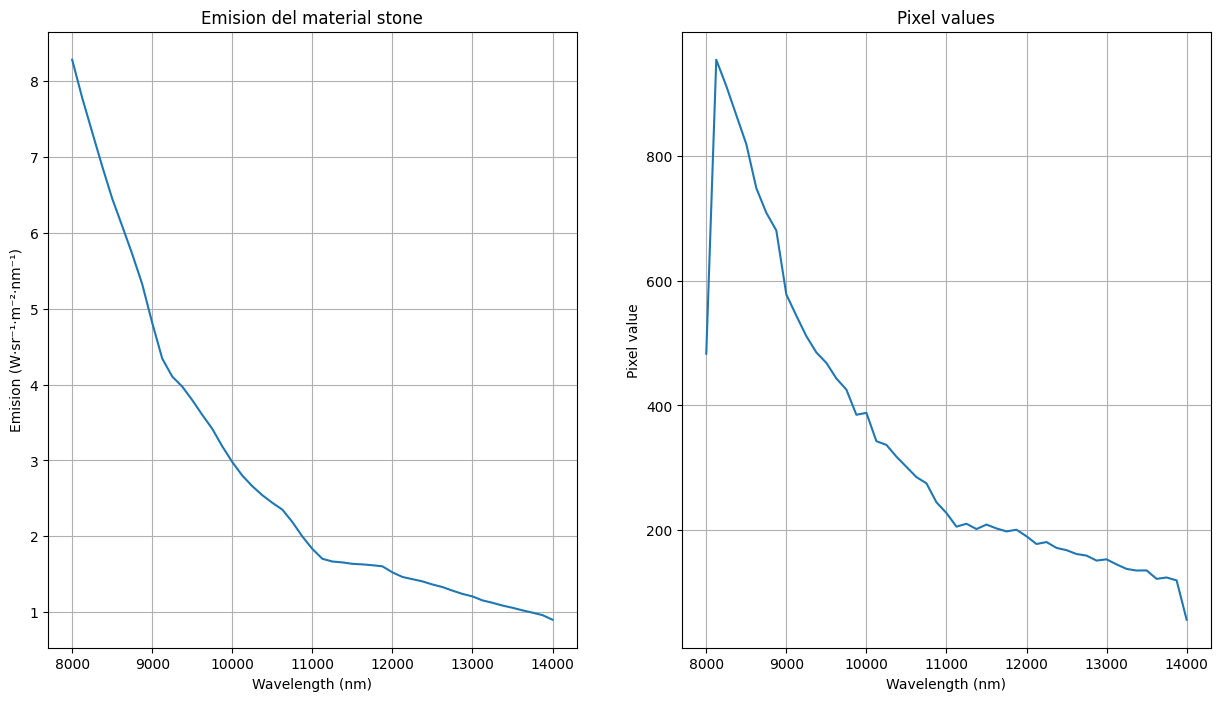

In [20]:
x = 200
y = 250

pixel = imagen_espectral[y, x, :].numpy()

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(wave_lengths, emision)
plt.title(f"Emision del material {material}")
plt.xlabel("Wavelength (nm)")


plt.ylabel("Emision (W·sr⁻¹·m⁻²·nm⁻¹)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, pixel)
plt.title("Pixel values")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value")
plt.grid()

plt.show()

## Agregango un medio absorbente

### Creamos el objeto de la niebla

In [21]:
niebla = {
    "type": "homogeneous",  # medio homogeneo, es decir el mismo sigma en todo el espacio,
    "id": "niebla",  # identificador del medio, para referenciarlo
    "albedo": {  # esto reprecenta el scattering del medio
        "type": "rgb",
        "value": [
            1.0,
            1.0,
            1.0,
        ],  # valor del albedo, reprecenta el "scattering" del medio, es decir la cantidad de luz que se dispersa en el medio
    },
    "sigma_t": 0.01,  # coeficente de atenuacion del medio, T(d) = exp(-sigma_t * d), donde d es la distancia recorrida en el medio
    "phase": {  # define como se dispersa la luz en el medio (no la he entendido bien)
        "type": "hg",
        "g": 0.0,
    },
}

### Asociamos al sensor, el medio

In [22]:
sensor_rgb_niebla = load_sensor_rgb(r, phi, theta)
sensor_rgb_niebla["medium"] = {"type": "ref", "id": "niebla"}

### Creamos el integrador para que permita el uso de este tipo de interacciones

In [23]:
integrador = {"type": "volpathmis", "max_depth": 8}

### Creacion de la escena

In [ ]:
scene = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador,
        "niebla": niebla,
        "sensor": sensor_rgb_niebla,
        # 'emitter': {
        #     'type' : 'constant'
        # },
        "dragon": dragon,
    }
)

: 

### Renderizamos RGB por ahora aver que pasa con la "niebla"

In [ ]:
imagen_rgb_niebla = mi.render(scene, spp=1024)

In [ ]:
print("Imagen RGB con niebla:")
print(imagen_rgb_niebla.shape)
print(np.min(imagen_rgb_niebla))
print(np.max(imagen_rgb_niebla))

Imagen RGB con niebla:
(256, 256, 3)
0.0
0.0


### Vamos a ver visualmente en RGB que sucede

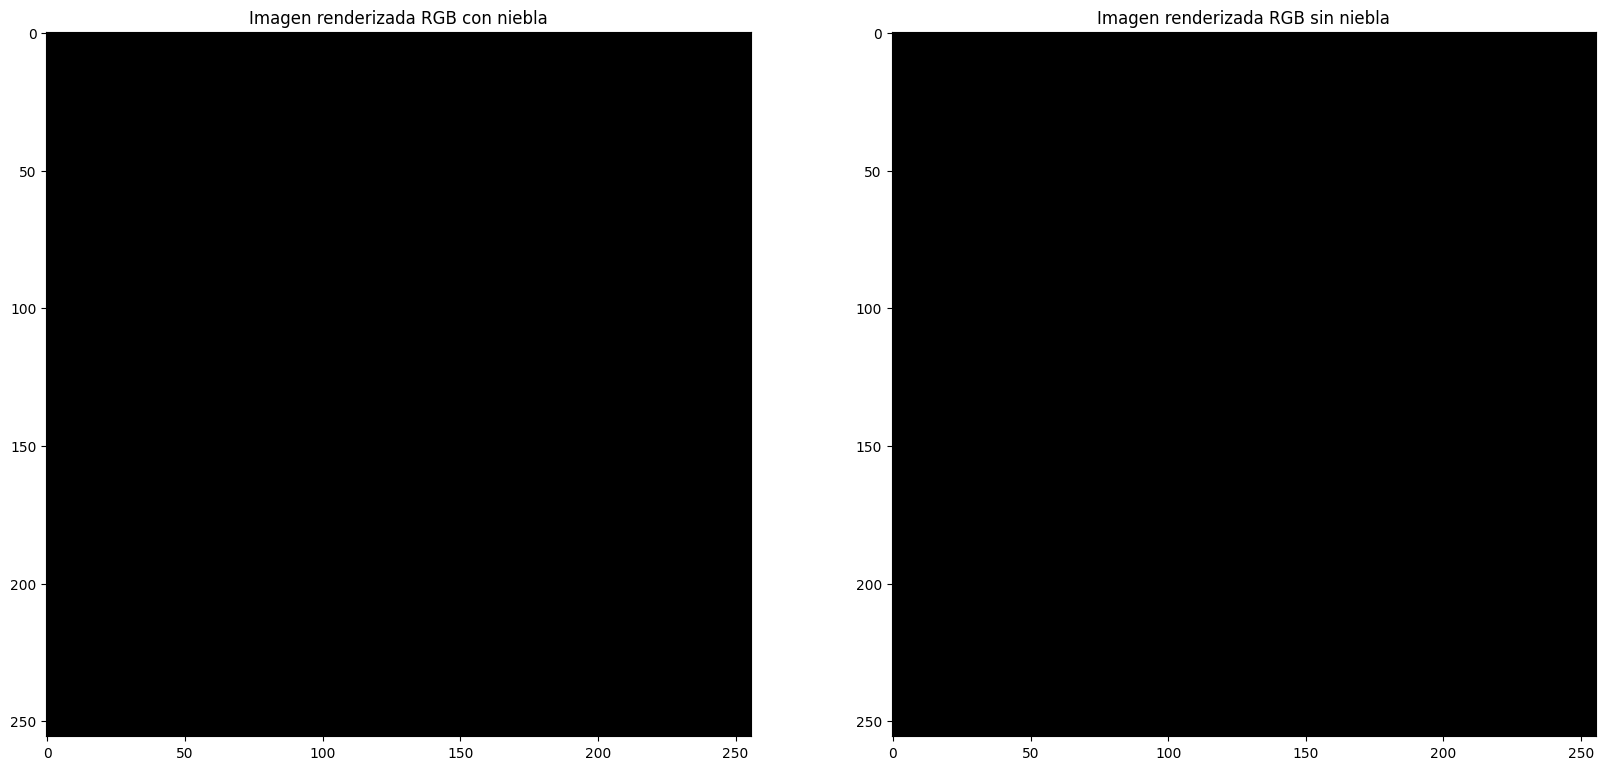

In [ ]:
## Gradicamos
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(imagen_rgb_niebla)
plt.title("Imagen renderizada RGB con niebla")
plt.subplot(1, 2, 2)
plt.imshow(imagen_rgb)
plt.title("Imagen renderizada RGB sin niebla")
plt.show()


## Ahora probemoslo con el spectral

In [ ]:
niebla = {
    "type": "homogeneous",  # medio homogeneo, es decir el mismo sigma en todo el espacio,
    "id": "niebla",  # identificador del medio, para referenciarlo
    "albedo": {
        "type": "constvolume",  # textura volumétrica constante
        "value": {"type": "uniform", "value": 0.0},
    },
    "sigma_t": {
        "type": "constvolume",
        "value": {
            "type": "irregular",  # definimos un espectro
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string([0.01] * len(wave_lengths)),
        },
    },
    "phase": {  # define como se dispersa la luz en el medio (no la he entendido bien)
        "type": "hg",
        "g": 0.95,  # usar valores de 0.9-0.95 que es lo que pasa en el infrarrojo lejano, preguntarle al profe
        # con este nuevo valor pareciera que no existiera niebla, pero si lo pongo en 0.0 se ve la niebla
    },
}

In [ ]:
sensor_espectral_niebla = load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
sensor_espectral_niebla["medium"] = {"type": "ref", "id": "niebla"}

In [ ]:
scene = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        # 'emitter': {
        #     'type' : 'constant'
        # },
        "dragon": dragon,
    }
)


In [49]:
scene_xml_path = r"C:\Users\mgefr\Documents\1UIS\proyecto-grado\output\static\scene_thermal.xml"
scene_from_xml = mi.load_file(scene_xml_path)

In [ ]:
image_test = mi.render(scene_from_xml)

In [52]:
print(image_test.shape)

(1080, 1920, 10)


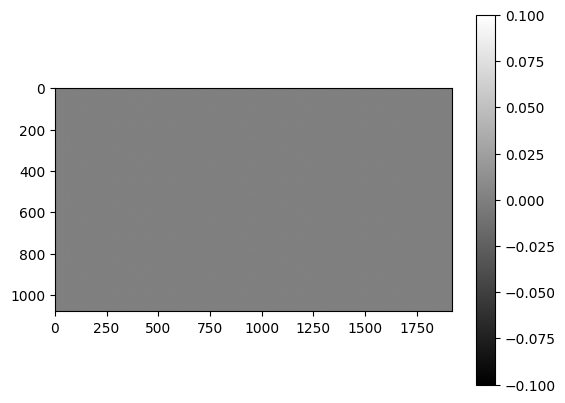

In [55]:
plt.imshow(image_test[:, :, 0], cmap='gray')
plt.colorbar()

In [ ]:
imagen_espectral_niebla = mi.render(scene, spp=1024 * 16)

In [ ]:
print("Imagen ESPECTRAL con niebla:")
print(imagen_espectral_niebla.shape)
print(np.min(imagen_espectral_niebla))
print(np.max(imagen_espectral_niebla))

Imagen ESPECTRAL con niebla:
(256, 256, 49)
0.0
750.0712


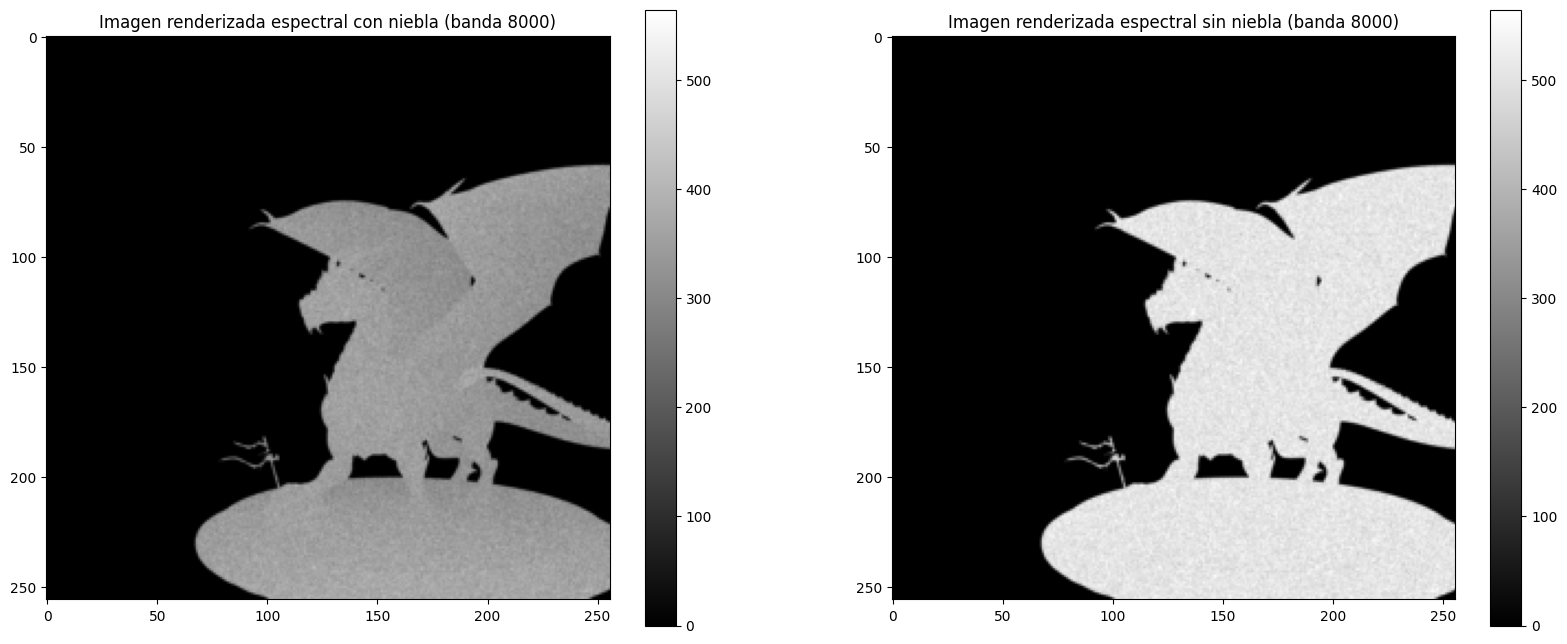

In [ ]:
banda = 0
min_value = np.min(imagen_espectral[:, :, banda])
max_value = np.max(imagen_espectral[:, :, banda])

### Plotear imagen espectral con niebla y sin niebla
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(
    imagen_espectral_niebla[:, :, banda], cmap="gray", vmin=min_value, vmax=max_value
)
plt.colorbar()
plt.title(
    "Imagen renderizada espectral con niebla (banda {})".format(wave_lengths[banda])
)

plt.subplot(1, 2, 2)
plt.imshow(imagen_espectral[:, :, banda], cmap="gray", vmin=min_value, vmax=max_value)
plt.colorbar()
plt.title(
    "Imagen renderizada espectral sin niebla (banda {})".format(wave_lengths[banda])
)

plt.show()

### Veamos los valores del pixel

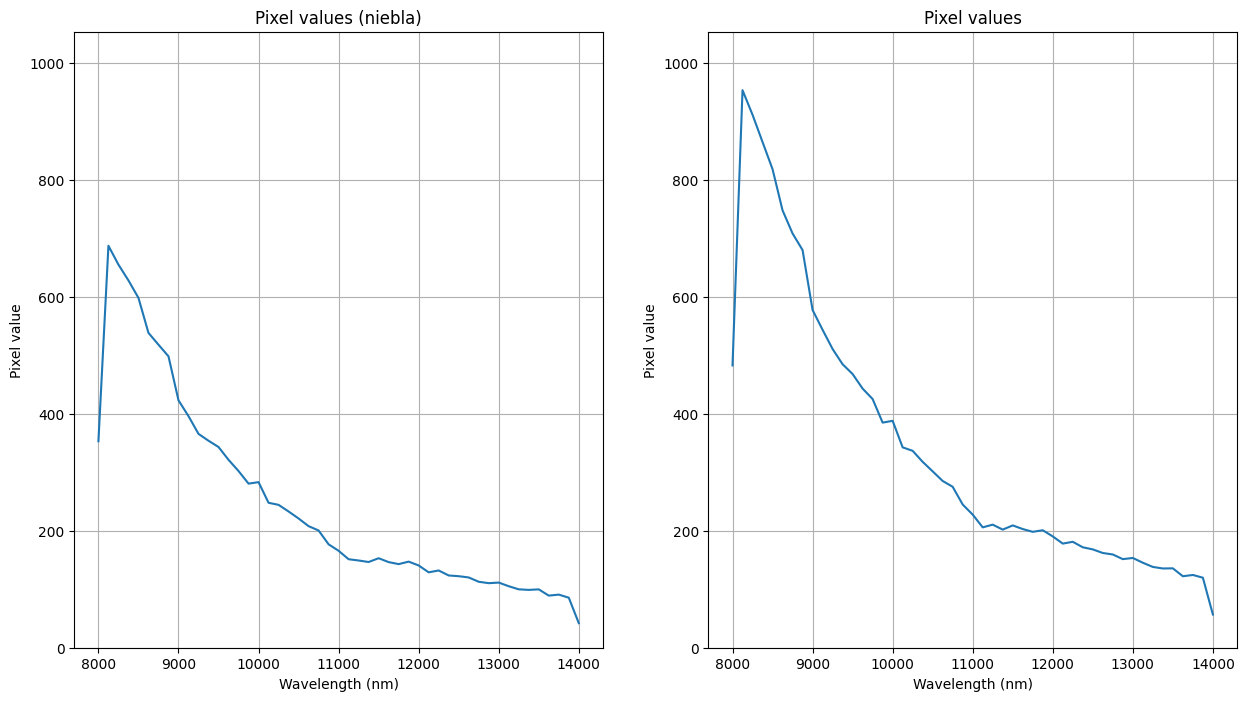

In [ ]:
x = 200
y = 250

pixel = imagen_espectral[y, x, :].numpy()
pixel_niebla = imagen_espectral_niebla[y, x, :].numpy()

pixel_max = np.max(pixel) + 100

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(wave_lengths, pixel_niebla)
plt.title("Pixel values (niebla)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value")
plt.ylim(0, pixel_max)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(wave_lengths, pixel)
plt.title("Pixel values")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value")
plt.ylim(0, pixel_max)
plt.grid()

plt.show()

Imagen ESPECTRAL con niebla albedo 0.0 y Sigma_t 1e-07:
(256, 256, 49)
0.0
1107.9688
Imagen ESPECTRAL con niebla albedo 0.0 y Sigma_t 0.005:
(256, 256, 49)
0.0
941.57574
Imagen ESPECTRAL con niebla albedo 0.0 y Sigma_t 0.01:
(256, 256, 49)
0.0
826.0621
Imagen ESPECTRAL con niebla albedo 0.5 y Sigma_t 1e-07:
(256, 256, 49)
0.0
1107.9688
Imagen ESPECTRAL con niebla albedo 0.5 y Sigma_t 0.005:
(256, 256, 49)
0.0062278053
997.7283
Imagen ESPECTRAL con niebla albedo 0.5 y Sigma_t 0.01:
(256, 256, 49)
0.013281126
921.10034
Imagen ESPECTRAL con niebla albedo 1.0 y Sigma_t 1e-07:
(256, 256, 49)
0.0
1107.9683
Imagen ESPECTRAL con niebla albedo 1.0 y Sigma_t 0.005:
(256, 256, 49)
0.013518834
1065.8602
Imagen ESPECTRAL con niebla albedo 1.0 y Sigma_t 0.01:
(256, 256, 49)
0.030464089
1047.3097


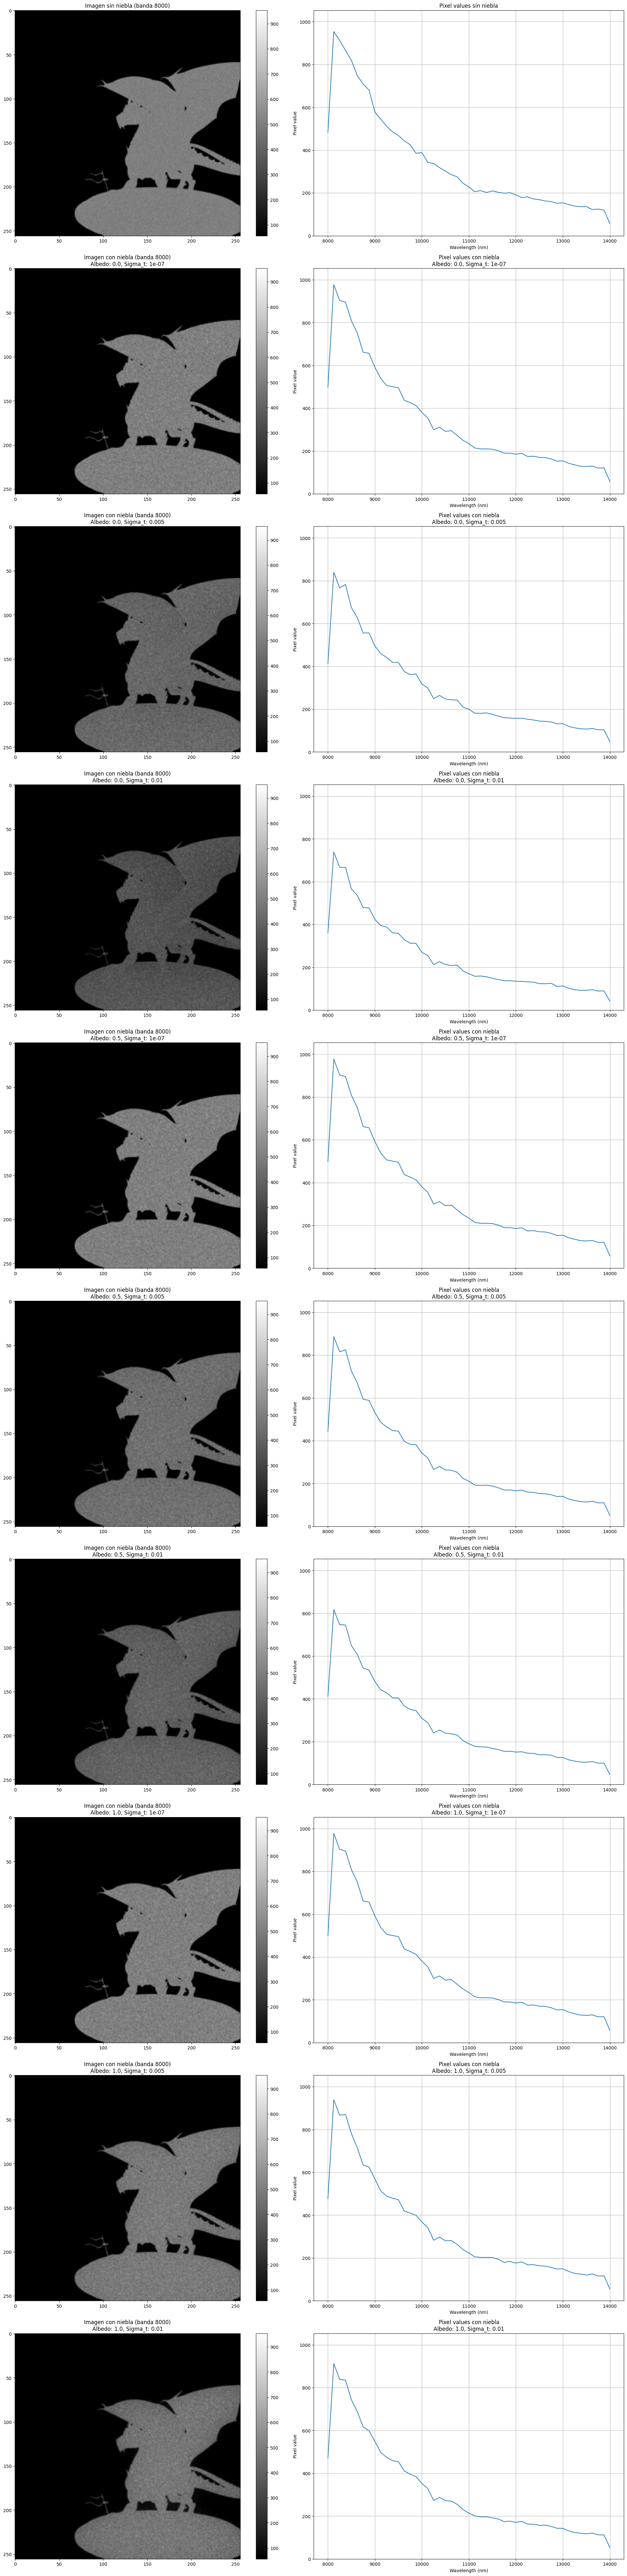

In [ ]:
valores_albedo = [0.0, 0.5, 1.0]
valores_sigma_t = [1e-7, 0.005, 0.01]

x = 200
y = 250

pixel = imagen_espectral[y, x, :].numpy()

banda = 0
min_value = np.min(pixel)
max_value = np.max(pixel)

n = len(valores_albedo) * len(valores_sigma_t) + 2

plt.figure(figsize=(20, n * 8))
plt.subplot(n, 2, 1)
plt.imshow(imagen_espectral[:, :, banda], cmap="gray", vmin=min_value, vmax=max_value)
plt.colorbar()
plt.title("Imagen sin niebla (banda {})".format(wave_lengths[banda]))

plt.subplot(n, 2, 2)
plt.plot(wave_lengths, pixel)
plt.title("Pixel values sin niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value")
plt.grid()
plt.ylim(0, max_value + 100)


i = 3

for albedo in valores_albedo:
    for sigma_t in valores_sigma_t:
        niebla = {
            "type": "homogeneous",
            "id": "niebla",
            "albedo": {
                "type": "constvolume",
                "value": {"type": "uniform", "value": albedo},
            },
            "sigma_t": {
                "type": "constvolume",
                "value": {
                    "type": "irregular",  # definimos un espectro
                    "wavelengths": lista_a_string(wave_lengths),
                    "values": lista_a_string([sigma_t] * len(wave_lengths)),
                },
            },
            "phase": {"type": "hg", "g": 0.95},
        }

        sensor_espectral_niebla = load_sensor_spectral(
            r, phi, theta, wave_lengths, sigma, k, n
        )
        sensor_espectral_niebla["medium"] = {"type": "ref", "id": "niebla"}

        scene = mi.load_dict(
            {
                "type": "scene",
                "integrator": integrador,
                "niebla": niebla,
                "sensor": sensor_espectral_niebla,
                # 'emitter': {
                #     'type' : 'constant'
                # },
                "dragon": dragon,
            }
        )

        imagen_espectral_niebla = mi.render(scene, spp=1024 * 4)

        print(
            "Imagen ESPECTRAL con niebla albedo {} y Sigma_t {}:".format(
                albedo, sigma_t
            )
        )
        print(imagen_espectral_niebla.shape)
        print(np.min(imagen_espectral_niebla))
        print(np.max(imagen_espectral_niebla))

        pixel_niebla = imagen_espectral_niebla[y, x, :].numpy()

        plt.subplot(n, 2, i)
        plt.imshow(
            imagen_espectral_niebla[:, :, banda],
            cmap="gray",
            vmin=min_value,
            vmax=max_value,
        )
        plt.colorbar()
        plt.title(
            "Imagen con niebla (banda {})\nAlbedo: {}, Sigma_t: {}".format(
                wave_lengths[banda], albedo, sigma_t
            )
        )

        plt.subplot(n, 2, i + 1)
        plt.plot(wave_lengths, pixel_niebla)
        plt.title(
            "Pixel values con niebla\nAlbedo: {}, Sigma_t: {}".format(albedo, sigma_t)
        )
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Pixel value")
        plt.grid()
        plt.ylim(0, max_value + 100)

        i += 2

plt.tight_layout()
plt.show()

## Sensor para calculo de profundidad (depth map)

In [ ]:
def load_sensor_depth(r, phi, theta):
    z = r * np.sin(math.radians(theta))
    y = r * np.cos(math.radians(theta)) * np.sin(math.radians(phi))
    x = r * np.cos(math.radians(theta)) * np.cos(math.radians(phi))

    origin = np.array([x, y, z])

    return {
        "type": "perspective",
        "fov": 40,
        "to_world": T().look_at(origin=origin, target=[0, 0, 0], up=[0, 0, 1]),
        "sampler": {"type": "independent", "sample_count": 1},
        "film": {
            "type": "hdrfilm",
            "width": 256,
            "height": 256,
            "rfilter": {"type": "box"},
            "pixel_format": "luminance",
            "component_format": "float32",
        },
    }


In [ ]:
dragon = {
    "type": "obj",
    "filename": "scenes/objects/dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

In [ ]:
rs = [30, 40, 50, 60]
phi = -45
theta = 0

In [ ]:
images = []

for r in rs:
    sensor = load_sensor_depth(r, phi, theta)
    # sensor = mi.load_dict(load_sensor_rgb(r, phi, theta))

    scene = mi.load_dict(
        {
            "type": "scene",
            "integrator": {
                "type": "depth",
            },
            "sensor": sensor,
            "dragon": dragon,
        }
    )

    imagen_dept = mi.render(scene, spp=1024)
    images.append(imagen_dept)

Max value in depth images: 77.118744
Depth image at r=30: shape=(256, 256, 1), min=0.0, max=46.70565414428711
Depth image at r=40: shape=(256, 256, 1), min=0.0, max=56.99498748779297
Depth image at r=50: shape=(256, 256, 1), min=0.0, max=67.3697509765625
Depth image at r=60: shape=(256, 256, 1), min=0.0, max=77.11874389648438


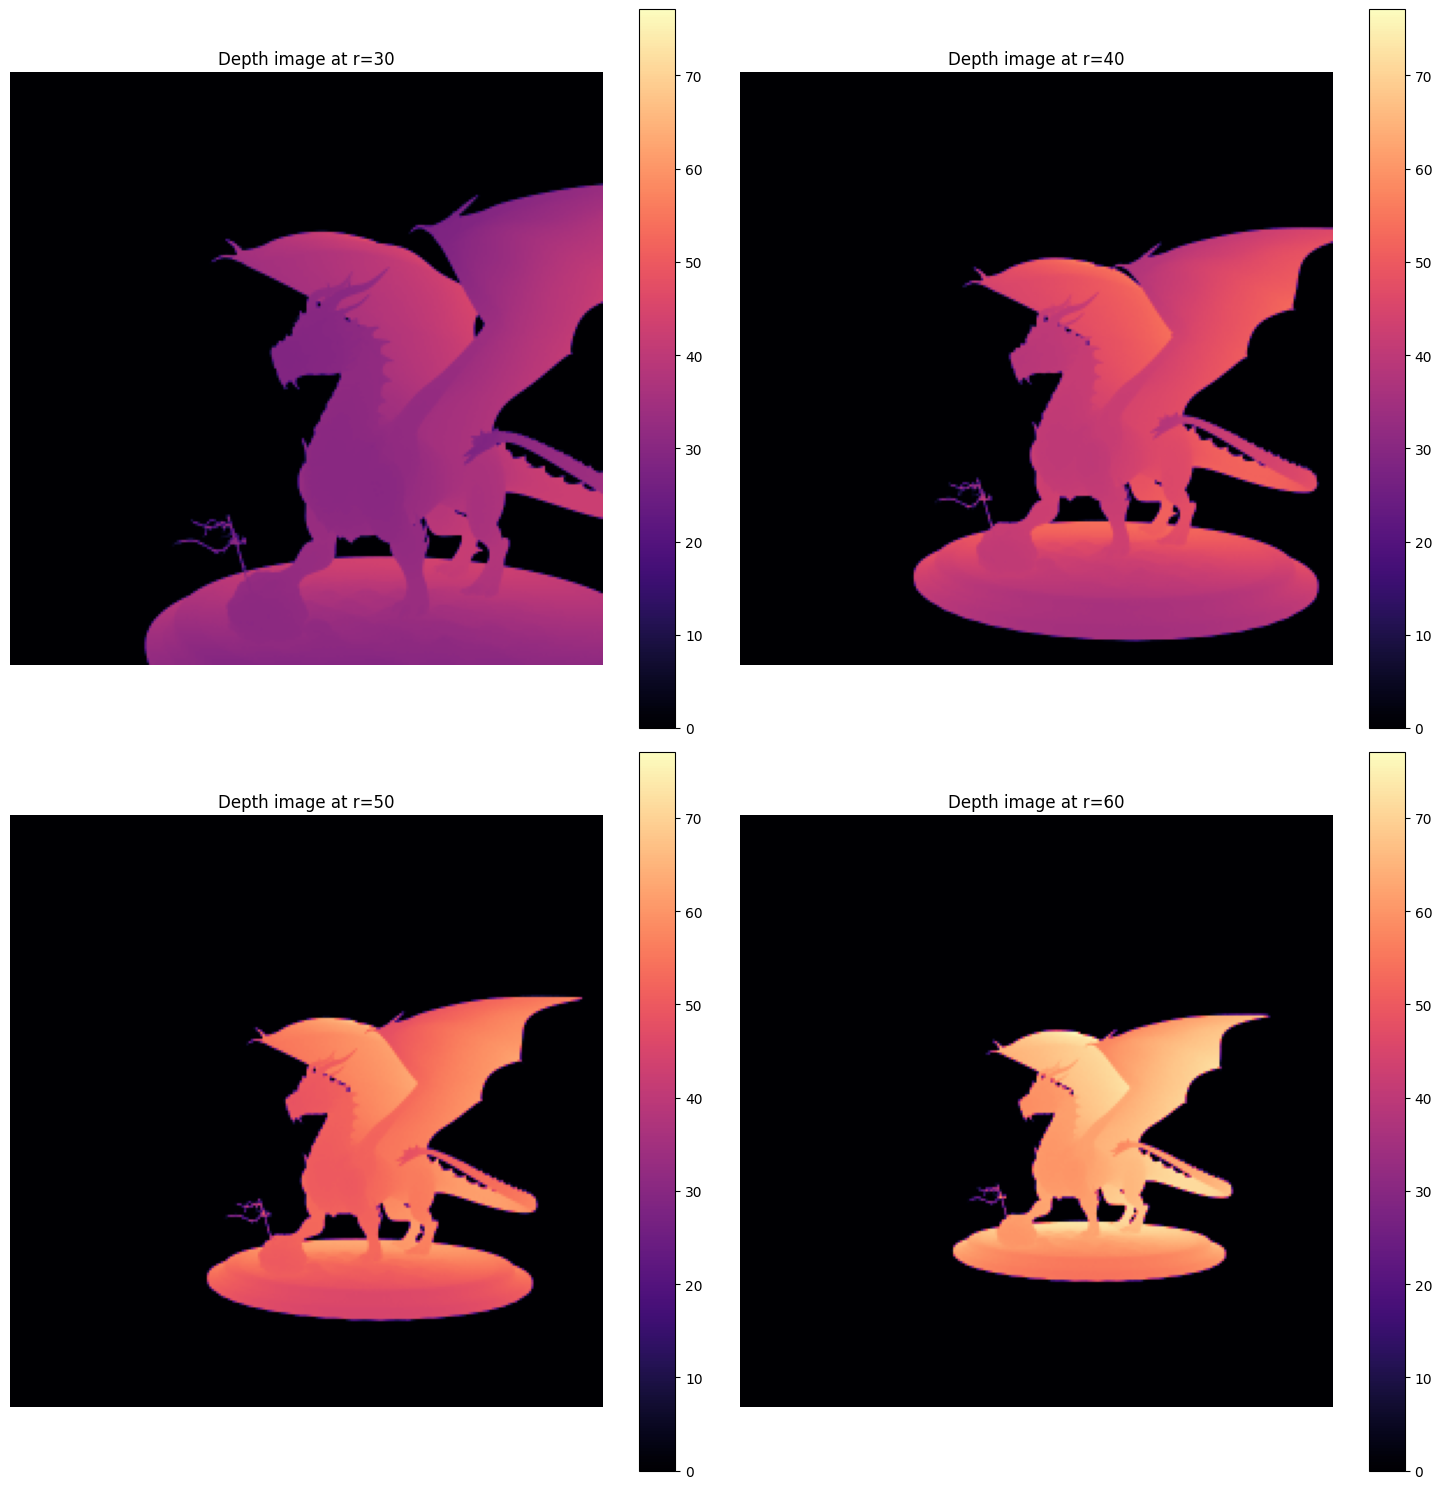

In [ ]:
max_value = np.max(images)
print("Max value in depth images:", max_value)

plt.figure(figsize=(15, 15))
for i, r in enumerate(rs):
    print(
        f"Depth image at r={r}: shape={images[i].shape}, min={np.min(images[i])}, max={np.max(images[i])}"
    )

    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap="magma", vmin=0, vmax=max_value)
    plt.title(f"Depth image at r={r}")
    plt.axis("off")
    plt.colorbar()

plt.tight_layout()
plt.show()

### Calculo de firma de transmitancia

In [ ]:
dragon = {
    "type": "obj",
    "filename": "scenes/objects/dragon.obj",
    "to_world": T().translate([0, 0, 0]),
    "emitter": {
        "type": "area",
        "radiance": {
            "type": "irregular",
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(emision),
        },
    },
}

In [ ]:
sigma = 10
r = 35
phi = -45
theta = 0
k = 3
n = 15

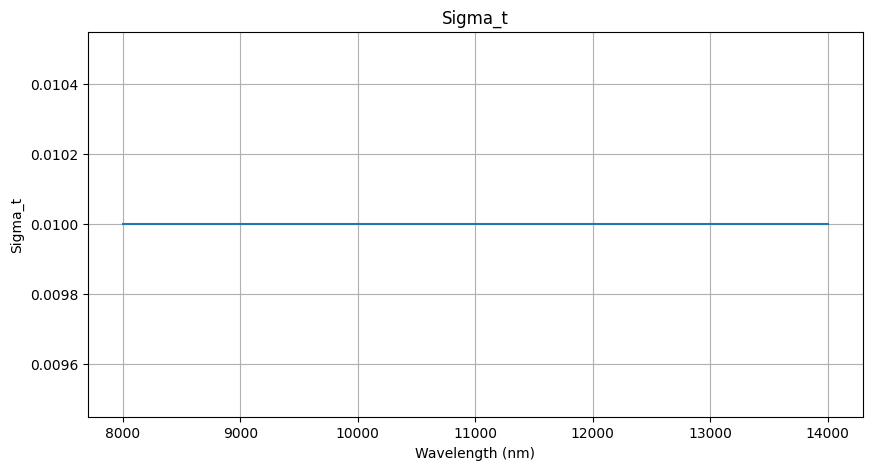

In [ ]:
## creacion de la firma de sigma_t

# constante
sigma_t = 0.01
lista_sigma_t_const = [sigma_t] * len(wave_lengths)


# irregular
sigma_t_min = 0.01
sigma_t_max = 0.1

lista_sigma_t_irregular = np.linspace(sigma_t_min, sigma_t_max, len(wave_lengths))

# select sigma_t_irregular[0] = sigma_t_min
sigmat_t = lista_sigma_t_const.copy()
# sigmat_t = lista_sigma_t_irregular.copy()

plt.figure(figsize=(10, 5))
plt.plot(wave_lengths, sigmat_t)
plt.title("Sigma_t")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Sigma_t")
plt.grid()
plt.show()

In [ ]:
niebla = {
    "type": "homogeneous",  # medio homogeneo, es decir el mismo sigma en todo el espacio,
    "id": "niebla",  # identificador del medio, para referenciarlo
    "albedo": {
        "type": "constvolume",  # textura volumétrica constante
        "value": {"type": "uniform", "value": 0.0},
    },
    "sigma_t": {
        "type": "constvolume",
        "value": {
            "type": "irregular",  # definimos un espectro
            "wavelengths": lista_a_string(wave_lengths),
            "values": lista_a_string(sigmat_t),
        },
    },
    "phase": {  # define como se dispersa la luz en el medio (no la he entendido bien)
        "type": "hg",
        "g": 0.95,  # usar valores de 0.9-0.95 que es lo que pasa en el infrarrojo lejano, preguntarle al profe
        # con este nuevo valor pareciera que no existiera niebla, pero si lo pongo en 0.0 se ve la niebla
    },
}

In [ ]:
sensor_espectral_niebla = load_sensor_spectral(r, phi, theta, wave_lengths, sigma, k, n)
sensor_espectral_niebla["medium"] = {"type": "ref", "id": "niebla"}

sensor_espectral_sin_niebla = load_sensor_spectral(
    r, phi, theta, wave_lengths, sigma, k, n
)

sensor_depth = load_sensor_depth(r, phi, theta)


In [ ]:
integrador_niebla = {"type": "volpathmis", "max_depth": 8}

integrador_sin_niebla = {"type": "path"}

In [ ]:
scene_sin_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_sin_niebla,
        "sensor": sensor_espectral_sin_niebla,
        "dragon": dragon,
    }
)

scene_niebla = mi.load_dict(
    {
        "type": "scene",
        "integrator": integrador_niebla,
        "niebla": niebla,
        "sensor": sensor_espectral_niebla,
        "dragon": dragon,
    }
)

scene_depth = mi.load_dict(
    {
        "type": "scene",
        "integrator": {
            "type": "depth",
        },
        "sensor": sensor_depth,
        "dragon": dragon,
    }
)

### Renderizacion de imagenes

In [ ]:
imagen_niebla = mi.render(scene_niebla, spp=1024 * 16)
imagen_sin_niebla = mi.render(scene_sin_niebla, spp=1024 * 16)
imagen_depth = mi.render(scene_depth, spp=1024 * 16)

### Visualizaicion de imagenes

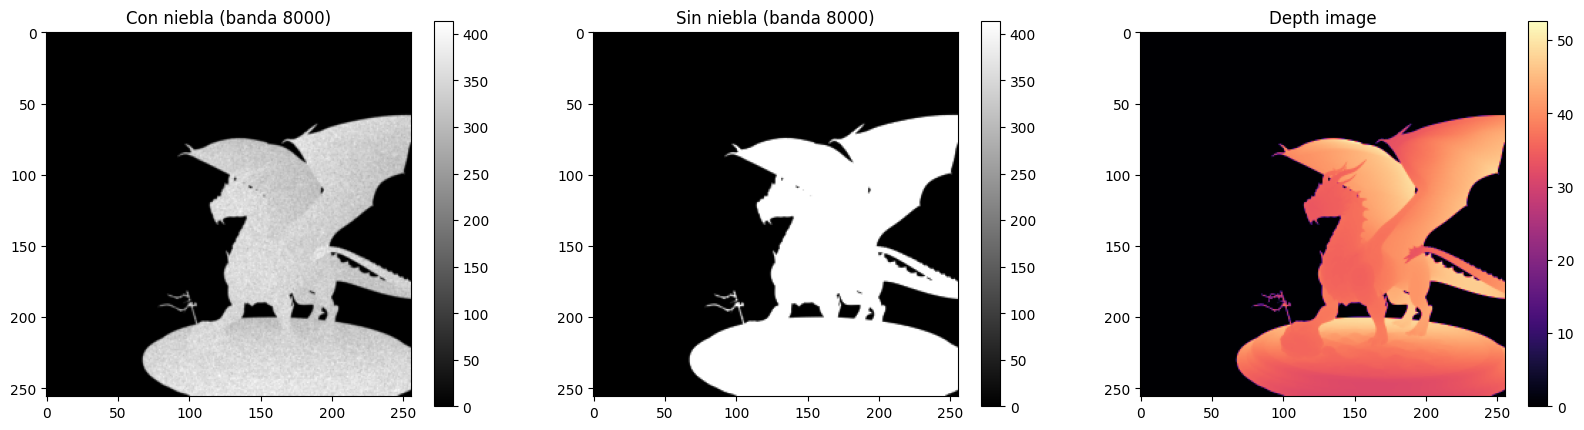

In [ ]:
banda = 0
min_value = np.min(imagen_niebla[:, :, banda])
max_value = np.max(imagen_niebla[:, :, banda])

plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.imshow(imagen_niebla[:, :, banda], cmap="gray", vmin=0, vmax=max_value)
plt.colorbar()
plt.title("Con niebla (banda {})".format(wave_lengths[banda]))

plt.subplot(1, 3, 2)
plt.imshow(imagen_sin_niebla[:, :, banda], cmap="gray", vmin=0, vmax=max_value)
plt.colorbar()
plt.title("Sin niebla (banda {})".format(wave_lengths[banda]))

plt.subplot(1, 3, 3)
plt.imshow(imagen_depth, cmap="magma")
plt.title("Depth image")
plt.colorbar()

plt.show()


### Visualizacion de firmas

Distancia al objeto (pixel): [31.924904]


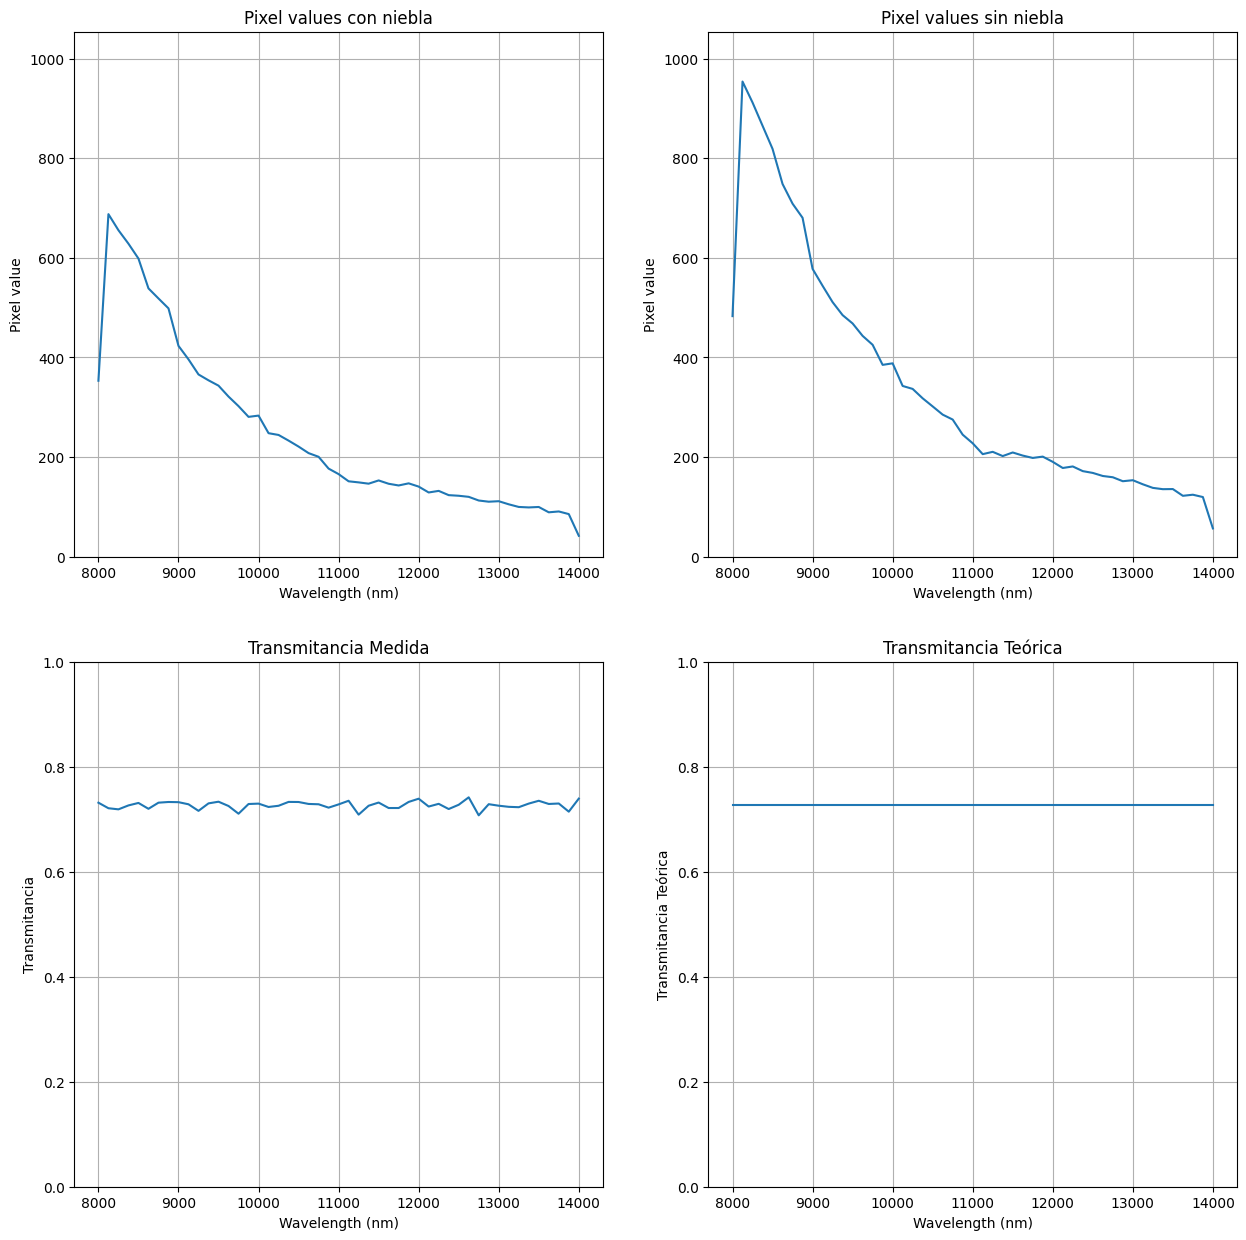

In [ ]:
x = 200
y = 250

pixel_niebla = imagen_niebla[y, x, :].numpy()
pixel_sin_niebla = imagen_sin_niebla[y, x, :].numpy()
ditancia = imagen_depth[y, x].numpy()

print("Distancia al objeto (pixel):", ditancia)

transmitancia_medicion = pixel_niebla / pixel_sin_niebla
transmitancia_teorica = np.exp(-np.array(sigmat_t) * ditancia)

pixel_max = np.max(pixel_sin_niebla) + 100

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(wave_lengths, pixel_niebla)
plt.title("Pixel values con niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value")
plt.ylim(0, pixel_max)
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(wave_lengths, pixel_sin_niebla)
plt.title("Pixel values sin niebla")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Pixel value")
plt.ylim(0, pixel_max)
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(wave_lengths, transmitancia_medicion)
plt.title("Transmitancia Medida")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmitancia")
plt.ylim(0, 1)
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(wave_lengths, transmitancia_teorica)
plt.title("Transmitancia Teórica")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmitancia Teórica")
plt.ylim(0, 1)
plt.grid()
